# Attention pattern inspection — top head per (size, motif) at step143000

**C2 deliverable per §H2-9-R.** A single representative attention heatmap per (size, motif), extracted from the top-scoring head at the final Pythia checkpoint (step143000). 9 panels total.

**Why this is here.** The Phase 2 sweep notebooks report scalar scores per (layer, head) for each motif. A reviewer needs to see whether those scores correspond to the *named behavior* — induction heads attending diagonally to the previous occurrence of the context, successor heads attending to the predecessor token, S-inhibition senders attending to S2 in IOI prompts. This notebook confirms that connection at one head per (size, motif).

**Top heads (extracted from Phase 2 + Phase 3 + Phase 4 sweep / anchor parquets at step143000):**

| size  | induction | successor | S-inhibition |
|-------|-----------|-----------|--------------|
| 70m   | L3H1 (0.86) | L4H0 (0.16) | L4H2 (0.04, sub-threshold)  |
| 160m  | L4H6 (0.88) | L9H10 (0.45) | L6H2 (0.07)  |
| 410m  | L11H14 (0.95) | L22H6 (0.29) | L12H12 (0.08)  |
| 1b    | L4H4 (0.93) | L11H6 (3.03) | L8H7 (0.069)  |
| 2.8b  | L6H2 (0.94) | L15H14 (2.13) | L11H29 (0.148)  |

70m S-inhibition is sub-threshold (τ_strict = 0.0372 not reached); the top head is shown anyway to confirm there is no S-inhibition behavior to inspect — the absence is the data point. The Phase 3 1B row is added per §H3-scale-8 (#7); the Phase 4 2.8B row uses anchor-checkpoint data per §H4-8 (the full 2.8B S-inhibition sweep was halted at 8/40 cells under §H4-7-supersede; the step143000 anchor data IS available and provides the top head for inspection).

## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
# Must be set before huggingface_hub is imported (the pythia_loader
# runtime workaround sets it too late for late-training Pythia-2.8B
# checkpoints which only have pytorch_model.bin, not safetensors).
os.environ.setdefault('HF_HUB_OFFLINE', '1')

import sys
import gc
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import torch
import matplotlib.pyplot as plt
from src.utils.pythia_loader import load_pythia
from src.utils.mps_compat import get_device

DEVICE = get_device()
print(f'Device: {DEVICE}')

# Top heads at step143000 per (size, motif), extracted from Phase 2
# sweep parquets via `df[(df.size==SIZE)&(df.step==143000)].nlargest(1, 'score')`.
TOP_HEADS = {
    ('70m', 'induction'): (3, 1),
    ('70m', 'successor'): (4, 0),
    ('70m', 's_inhibition'): (4, 2),
    ('160m', 'induction'): (4, 6),
    ('160m', 'successor'): (9, 10),
    ('160m', 's_inhibition'): (6, 2),
    ('410m', 'induction'): (11, 14),
    ('410m', 'successor'): (22, 6),
    ('410m', 's_inhibition'): (12, 12),
    # Phase 3 1B (§H3-scale-8 #7) — top heads at step143000
    ('1b', 'induction'): (4, 4),
    ('1b', 'successor'): (11, 6),
    ('1b', 's_inhibition'): (8, 7),
    # Phase 4 2.8B (§H4-8) — anchor-checkpoint top heads (sweep at
    # 2.8B for S-inhibition was halted at 8/40 cells under
    # §H4-7-supersede; the step143000 anchor parquets contain the
    # full 5-size step143000 detection grid and provide the top heads).
    ('2.8b', 'induction'): (6, 2),
    ('2.8b', 'successor'): (15, 14),
    ('2.8b', 's_inhibition'): (11, 29),
}

SIZES = ['70m', '160m', '410m', '1b', '2.8b']
MOTIFS = ['induction', 'successor', 's_inhibition']
FINAL_STEP = 143000

Device: mps


## Define one representative prompt per motif

Each prompt is short (so the heatmap is legible) and specifically designed to elicit the named motif behavior:

- **Induction**: a 4-token random prefix repeated once. Induction   heads should show diagonal attention from each second-occurrence   token to the *next* token after the same content's first   occurrence.
- **Successor**: a short ordinal sequence ("Monday Tuesday").   Successor heads on the second token should attend to the first.
- **S-inhibition**: a canonical IOI prompt. S-inhibition senders   on the END token should attend to the S2 (second mention of   the subject) position.

In [2]:
PROMPTS = {
    'induction': 'When Mary and John went to the store, Mary and',
    'successor': 'Monday Tuesday Wednesday Thursday',
    's_inhibition': 'When John and Mary went to the store, John gave a drink to',
}

# Induction prompt: 'Mary and' appears twice. Induction heads at the
# second 'Mary' should attend to 'and' (the next token after the first 'Mary').
# This is the classical Olsson induction signature.
for motif, p in PROMPTS.items():
    print(f'  {motif}: "{p}"')

  induction: "When Mary and John went to the store, Mary and"
  successor: "Monday Tuesday Wednesday Thursday"
  s_inhibition: "When John and Mary went to the store, John gave a drink to"


## Extract attention pattern at the top head per (size, motif)

Loads each Pythia checkpoint once, extracts attention for all 3 motif prompts at that size's top-3 heads, then unloads to free memory before the next size. With 64 GB unified memory, the three models could be held simultaneously; sequential loading is more conservative.

In [3]:
patterns = {}  # {(size, motif): {'tokens': [...], 'attn': np.ndarray (dst, src)}}

for size in SIZES:
    print(f'\nLoading Pythia-{size} at step{FINAL_STEP} ...')
    # Use repo's existing loader which handles the empty-Bearer auth bug
    # by routing through HF_HUB_OFFLINE when checkpoint is locally cached.
    model = load_pythia(size, step=FINAL_STEP, device=DEVICE)
    model.eval()
    print(f'  loaded; n_layers={model.cfg.n_layers}, n_heads={model.cfg.n_heads}')
    for motif in MOTIFS:
        layer, head = TOP_HEADS[(size, motif)]
        prompt = PROMPTS[motif]
        tokens = model.to_str_tokens(prompt)
        with torch.no_grad():
            _, cache = model.run_with_cache(prompt)
        attn = cache['pattern', layer][0, head].detach().to('cpu').numpy()
        patterns[(size, motif)] = {'tokens': tokens, 'attn': attn,
                                    'layer': layer, 'head': head}
        print(f'  {motif} L{layer}H{head}: extracted attention shape {attn.shape}')
    del model
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
print('\nAll 9 attention patterns extracted.')


Loading Pythia-70m at step143000 ...


/Users/cberg/Documents/Emergence_Research/pythia-motif-emergence/.venv/lib/python3.12/site-packages/transformer_lens/config/HookedTransformerConfig.py:341: UserWarning: MPS backend may produce silently incorrect results (PyTorch 2.11.0). Set TRANSFORMERLENS_ALLOW_MPS=1 to suppress this warning. See: https://github.com/TransformerLensOrg/TransformerLens/issues/1178
  warn_if_mps(self.device)


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-70m-deduped into HookedTransformer
  loaded; n_layers=6, n_heads=8
  induction L3H1: extracted attention shape (11, 11)
  successor L4H0: extracted attention shape (4, 4)
  s_inhibition L4H2: extracted attention shape (14, 14)

Loading Pythia-160m at step143000 ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

Loaded pretrained model EleutherAI/pythia-2.8b-deduped into HookedTransformer


  loaded; n_layers=32, n_heads=32
  induction L6H2: extracted attention shape (10, 10)


  successor L15H14: extracted attention shape (3, 3)
  s_inhibition L11H29: extracted attention shape (13, 13)



All 9 attention patterns extracted.


## 9-panel attention figure (3 sizes × 3 motifs)

Each cell shows attention from destination tokens (rows) to source tokens (columns) for the top head of that motif at step143000. Numbers in cells are the actual attention weights.

**What to look for per motif:**
- **Induction**: diagonal-shifted attention. From the second "Mary"   position, attention should concentrate on the token *after* the   first "Mary".
- **Successor**: attention from each ordinal-token-position to the   preceding ordinal token in 410m's L22H6. Weaker or absent in 70m's   sub-threshold case.
- **S-inhibition**: attention from the END position (the IOI   predicted-token position) to S2 (second occurrence of John). The   attention is *what* gets suppressed, hence S-inhibition's name.


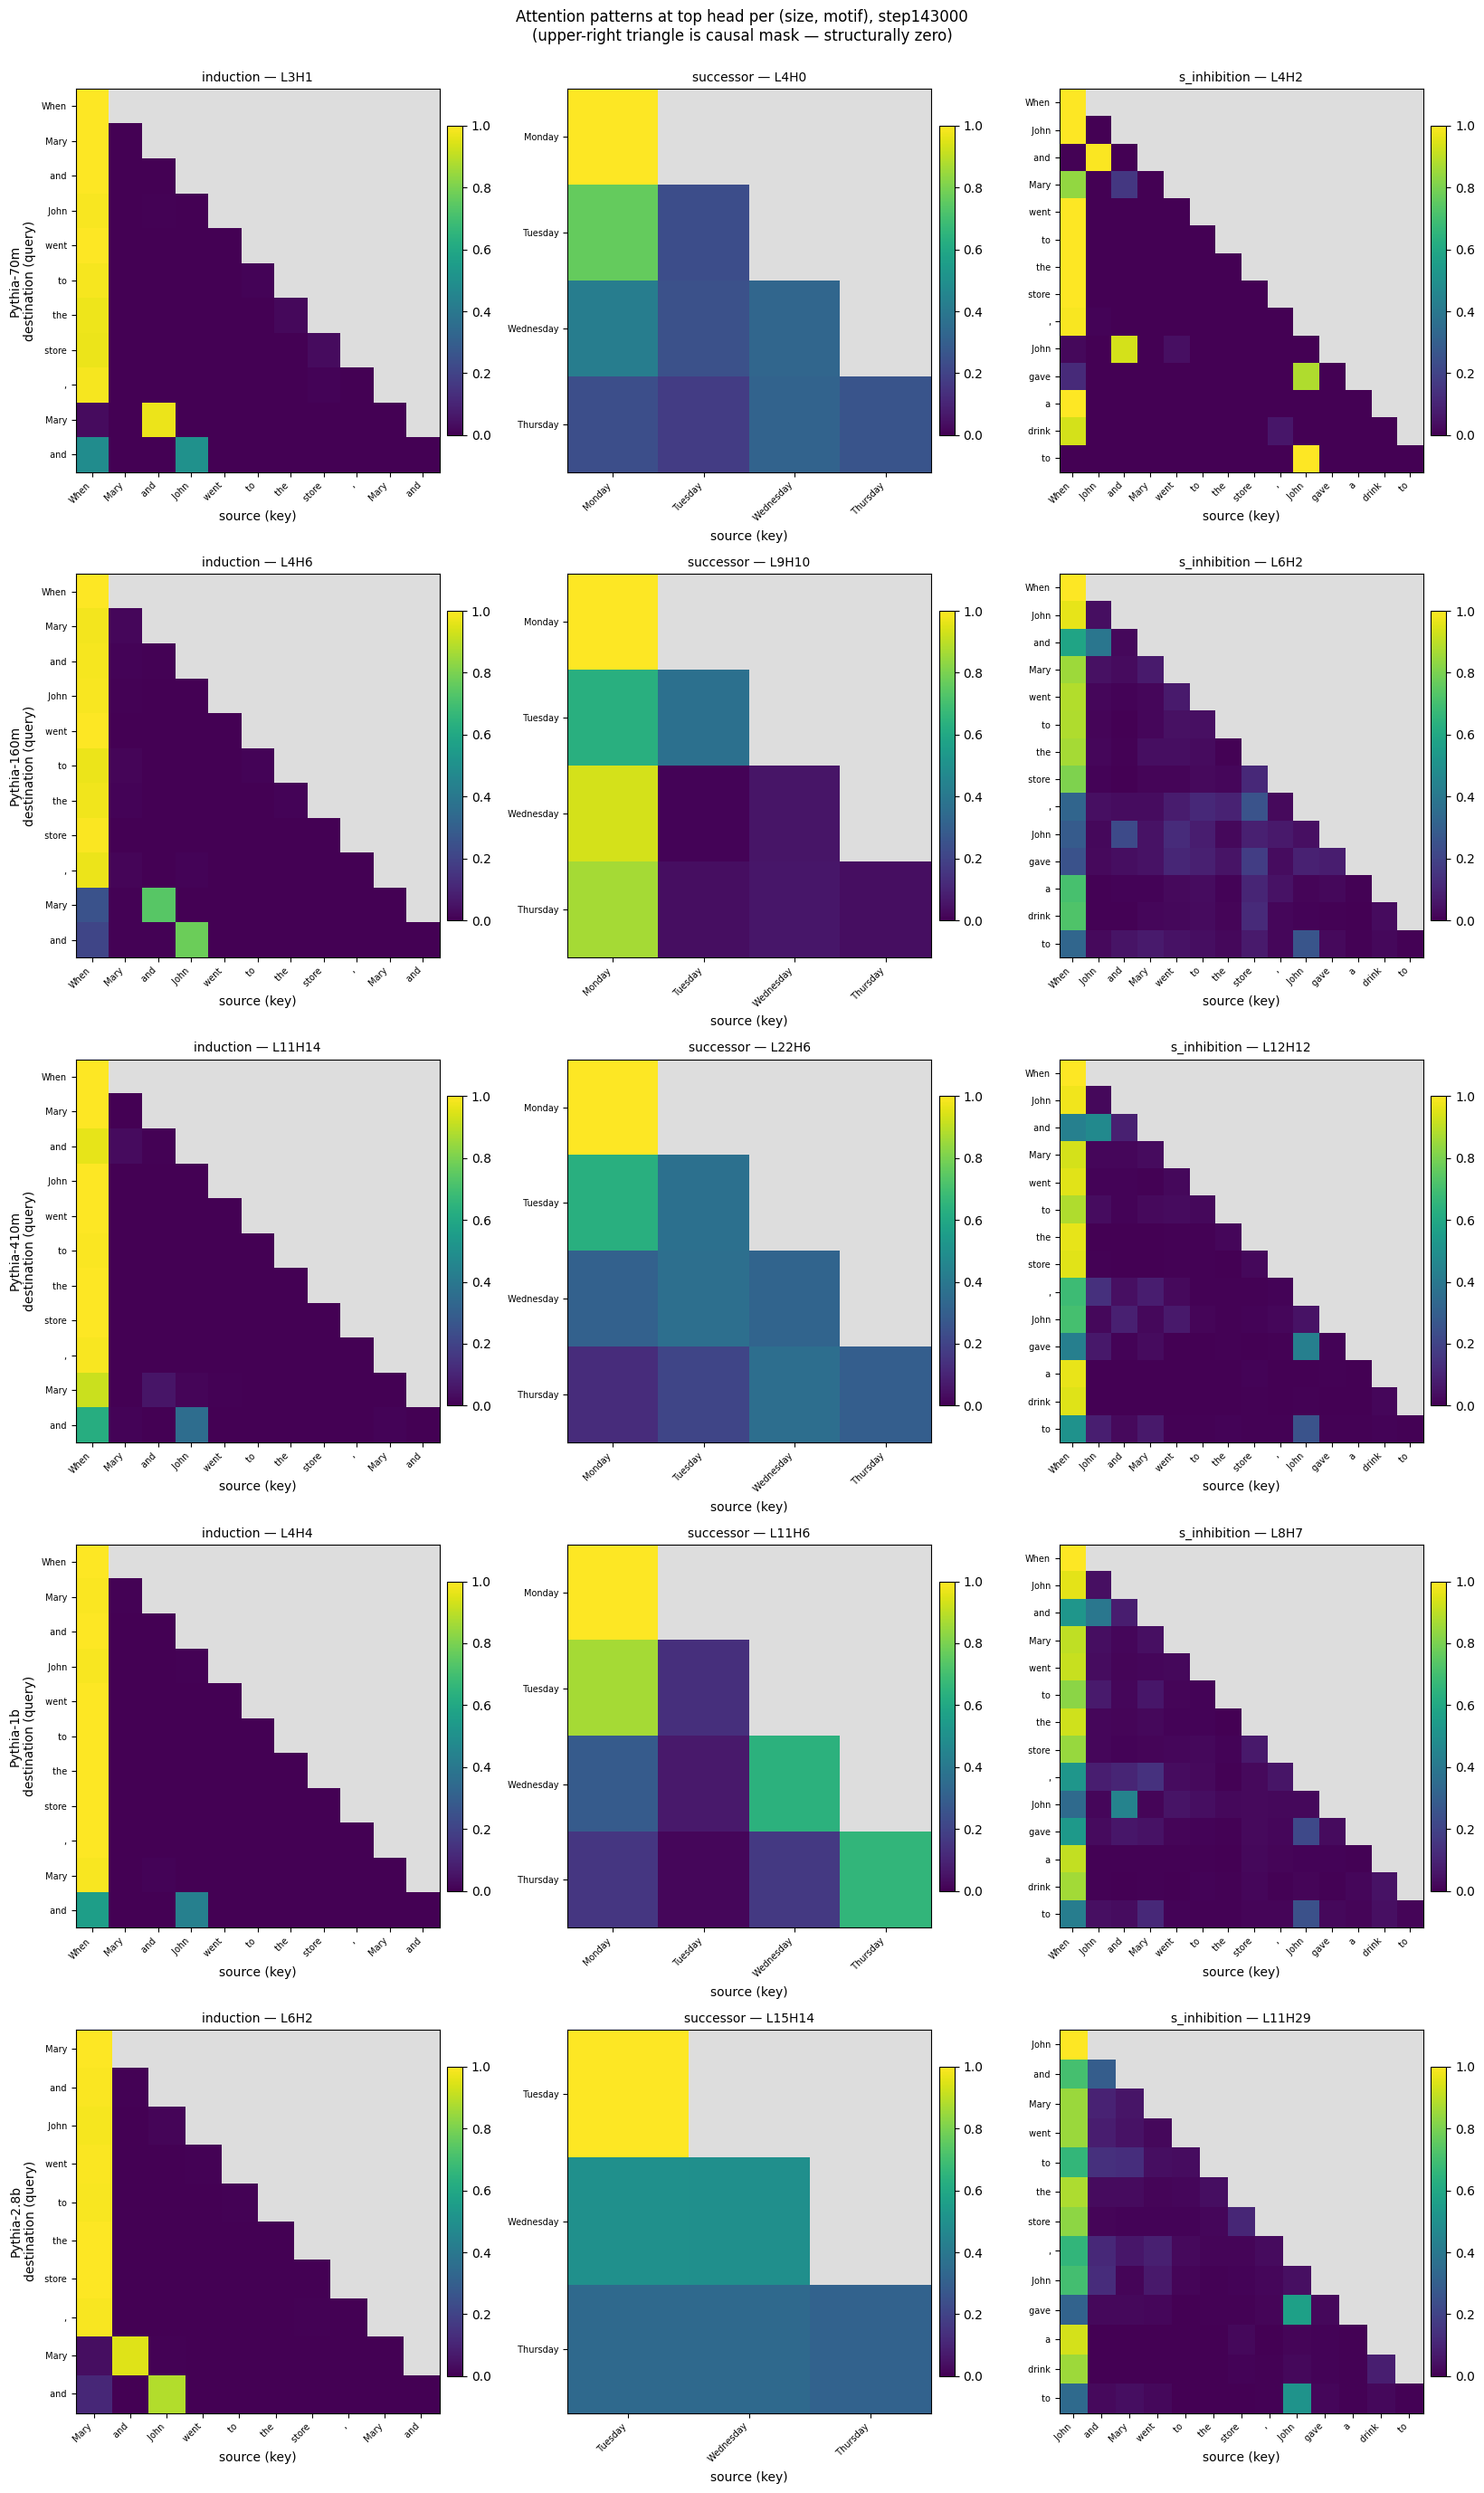

In [4]:
import matplotlib as mpl

# Build a colormap that renders masked cells (upper-right causal mask)
# as a neutral gray rather than white, so the diagonal is visually clear.
cmap = mpl.colormaps['viridis'].copy()
cmap.set_bad(color='#dddddd')

fig, axes = plt.subplots(
    len(SIZES), len(MOTIFS),
    figsize=(5.5 * len(MOTIFS), 5.5 * len(SIZES)),
    squeeze=False,
)
for row, size in enumerate(SIZES):
    for col, motif in enumerate(MOTIFS):
        ax = axes[row][col]
        d = patterns[(size, motif)]
        attn = d['attn']
        toks = d['tokens']
        layer, head = d['layer'], d['head']
        # Mask the upper-right triangle (causal mask: dst can only attend
        # to src ≤ dst, so the strict upper triangle is structurally zero).
        mask = np.triu(np.ones_like(attn, dtype=bool), k=1)
        attn_masked = np.ma.masked_where(mask, attn)
        im = ax.imshow(attn_masked, vmin=0, vmax=1, cmap=cmap, aspect='auto')
        ax.set_xticks(range(len(toks)))
        ax.set_yticks(range(len(toks)))
        ax.set_xticklabels(toks, rotation=45, ha='right', fontsize=7)
        ax.set_yticklabels(toks, fontsize=7)
        ax.set_xlabel('source (key)')
        if col == 0:
            ax.set_ylabel(f'Pythia-{size}\ndestination (query)')
        ax.set_title(f'{motif} — L{layer}H{head}', fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
fig.suptitle('Attention patterns at top head per (size, motif), step143000\n'
             '(upper-right triangle is causal mask — structurally zero)', y=1.0)
plt.tight_layout()
plt.show()

## Interpretation

The figure either confirms or undermines the score-based detector for each (size, motif). Two readings to look for:

**Confirming reading.** The attention pattern shows the named motif behavior at the threshold-passing heads. The score-based emergence claim is grounded in actual circuit-level attention behavior.

**Disconfirming reading.** The attention pattern doesn't show the named behavior even at the top head. The score-based claim is mechanistically suspicious. This is most likely to surface for the marginal/censored cells: 70m S-inhibition (sub-threshold), 70m successor (max_count=2), 160m S-inhibition (marginal). For those cells, the absence of clear named behavior is the *positive evidence* for the §H2-9-R reframe — these aren't underpowered measurements of a present motif; the motif simply isn't there yet at that scale.

**Cross-reference with the depth finding.** Pythia-410m successor at L22H6 sits at near-final layer depth (0.96); S-inhibition at L12H12 sits mid-network (0.52). The architectural-upstream-vs-downstream relationship is visible in the layer indices alone, and the attention patterns confirm both heads exhibit their named behavior despite the unexpected depth ordering.